# hand2string — CTC Baseline
End-to-end continuous sign language recognition with **CTC loss**.  
Input: MediaPipe landmark sequences `(T, FEAT_DIM)` produced by the preprocessing notebook.  
Output: transcribed English sentence trained with `nn.CTCLoss` over a character vocabulary.

**Pipeline:** Manifest → Tokenizer → Dataset → BiLSTM encoder → CTC head → Greedy decode → CER

## 0 · Imports

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import yaml
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.notebook import tqdm

# ── Repo root ──────────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "hand2string" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

sns.set_theme(style="whitegrid", palette="muted")
print(f"Repo root : {REPO_ROOT}")
print(f"PyTorch   : {torch.__version__}")
print("Imports OK")

Repo root : /home/louis/epfl/ma2/cs/hand2string
PyTorch   : 2.10.0
Imports OK


## 1 · Config & paths

In [2]:
# ── Config ─────────────────────────────────────────────────────────────────────
with open(REPO_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

# ── Paths ──────────────────────────────────────────────────────────────────────
LANDMARK_ROOT  = REPO_ROOT / "data" / "how2sign_landmarks"
MANIFEST_PATH  = LANDMARK_ROOT / "manifest.parquet"
TOKENIZER_PATH = REPO_ROOT / "runs" / "ctc_baseline" / "tokenizer.json"
CHECKPOINT_DIR = REPO_ROOT / "runs" / "ctc_baseline"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters ───────────────────────────────────────────────────────────
BATCH_SIZE   = 4
HIDDEN_DIM   = 256
N_LAYERS     = 2
DROPOUT      = 0.3
EPOCHS       = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.10
SEED         = 42
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load manifest ──────────────────────────────────────────────────────────────
manifest = pd.read_parquet(MANIFEST_PATH)
manifest = manifest[manifest["npy_path"].apply(os.path.exists)].reset_index(drop=True)

# ── Detect feature dim: use the majority, drop any mismatched legacy files ─────
_dims    = [int(np.load(p, mmap_mode="r").shape[1]) for p in manifest["npy_path"]]
FEAT_DIM = max(set(_dims), key=_dims.count)
n_before = len(manifest)
manifest = manifest[[d == FEAT_DIM for d in _dims]].reset_index(drop=True)
if len(manifest) < n_before:
    print(f"[config] Dropped {n_before - len(manifest)} file(s) with mismatched feat dim")

print(f"Device    : {DEVICE}")
print(f"Clips     : {len(manifest)}")
print(f"Feat dim  : {FEAT_DIM}")
print(f"Batch     : {BATCH_SIZE}  |  Hidden: {HIDDEN_DIM}  |  Layers: {N_LAYERS}")
print(f"Epochs    : {EPOCHS}  |  LR: {LR}  |  Val: {int(VAL_FRAC*100)}%")

[config] Dropped 1 file(s) with mismatched feat dim
Device    : cuda
Clips     : 346
Feat dim  : 384
Batch     : 4  |  Hidden: 256  |  Layers: 2
Epochs    : 40  |  LR: 0.001  |  Val: 10%


## 2 · Tokenizer
Character-level vocabulary (52 tokens): `<blank>` at index 0 is the CTC blank, followed by `<pad>`, `<unk>`, and printable characters.

In [3]:
with open(TOKENIZER_PATH) as f:
    VOCAB = json.load(f)   # list of token strings

char2idx  = {ch: i for i, ch in enumerate(VOCAB)}
idx2char  = {i: ch for i, ch in enumerate(VOCAB)}

BLANK_IDX  = char2idx["<blank>"]
PAD_IDX    = char2idx["<pad>"]
UNK_IDX    = char2idx["<unk>"]
VOCAB_SIZE = len(VOCAB)


def encode(text: str) -> list:
    """Lowercase text → list of token indices."""
    return [char2idx.get(c, UNK_IDX) for c in text.lower()]


def decode_indices(indices) -> str:
    """Index list → string (skips blank and pad)."""
    skip = {BLANK_IDX, PAD_IDX}
    return "".join(idx2char.get(i, "?") for i in indices if i not in skip)


def ctc_greedy_decode(log_probs: torch.Tensor) -> str:
    """Greedy CTC: argmax → collapse consecutive repeats → remove blank.
    log_probs: (T, C)
    """
    indices = log_probs.argmax(dim=-1).tolist()
    if not indices:
        return ""
    collapsed = [indices[0]]
    for idx in indices[1:]:
        if idx != collapsed[-1]:
            collapsed.append(idx)
    return decode_indices(i for i in collapsed if i != BLANK_IDX)


print(f"Vocab size : {VOCAB_SIZE}")
print(f"Blank idx  : {BLANK_IDX}")
print(f"Vocab      : {VOCAB}")
print()
ex = "Hello, World!"
enc = encode(ex)
print(f"encode('{ex}') = {enc}")
print(f"decode back    = '{decode_indices(enc)}'")

Vocab size : 51
Blank idx  : 0
Vocab      : ['<blank>', '<pad>', '<unk>', '<sp>', ' ', '!', '"', '$', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', ':', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

encode('Hello, World!') = [32, 29, 36, 36, 39, 11, 4, 47, 39, 42, 36, 28, 5]
decode back    = 'hello, world!'


## 3 · Dataset & DataLoader
Each sample is a **full clip** (no windowing): `(T, FEAT_DIM)` paired with the encoded sentence.  
Clips where `T < len(target)` are dropped — CTC requires the input sequence to be at least as long as the target.

In [4]:
class CTCSignDataset(Dataset):
    """Full-sequence landmark dataset for CTC training."""

    def __init__(self, df: pd.DataFrame):
        self.records = []
        dropped = 0
        for _, row in df.iterrows():
            tgt = encode(row["sentence"])
            T   = np.load(row["npy_path"], mmap_mode="r").shape[0]
            if T >= len(tgt):   # CTC constraint
                self.records.append((row["npy_path"], tgt))
            else:
                dropped += 1
        if dropped:
            print(f"[CTCSignDataset] Dropped {dropped} clips (T < target length)")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, tgt = self.records[idx]
        x = torch.from_numpy(np.load(path)).float()   # (T, FEAT_DIM)
        y = torch.tensor(tgt, dtype=torch.long)        # (L,)
        return x, y


def collate_ctc(batch):
    """Pad variable-length sequences; build CTC-compatible tensors."""
    xs, ys = zip(*batch)
    input_lengths  = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    target_lengths = torch.tensor([y.shape[0] for y in ys],  dtype=torch.long)
    x_pad = pad_sequence(xs, batch_first=True)   # (B, T_max, FEAT_DIM)
    y_cat = torch.cat(ys)                          # (sum of target_lengths,)
    return x_pad, y_cat, input_lengths, target_lengths


# ── Split ──────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
full_ds = CTCSignDataset(manifest)
n_val   = max(1, int(len(full_ds) * VAL_FRAC))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_train, n_val])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      collate_fn=collate_ctc, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      collate_fn=collate_ctc, num_workers=2, pin_memory=True)

# ── Sanity check ───────────────────────────────────────────────────────────────
x_b, y_b, il, tl = next(iter(train_dl))
print(f"Dataset        : {len(full_ds)} clips  ({n_train} train / {n_val} val)")
print(f"x_batch shape  : {tuple(x_b.shape)}  (B, T_max, FEAT_DIM)")
print(f"targets shape  : {tuple(y_b.shape)}  (concatenated target indices)")
print(f"input_lengths  : {il.tolist()}")
print(f"target_lengths : {tl.tolist()}")
print(f"T >= L for all : {(il >= tl).all().item()}")

[CTCSignDataset] Dropped 2 clips (T < target length)
Dataset        : 344 clips  (310 train / 34 val)
x_batch shape  : (4, 434, 384)  (B, T_max, FEAT_DIM)
targets shape  : (634,)  (concatenated target indices)
input_lengths  : [339, 136, 177, 434]
target_lengths : [283, 64, 86, 201]
T >= L for all : True


## 4 · CTC Model

```
(B, T, FEAT_DIM)
  └→ Linear(FEAT_DIM → HIDDEN_DIM) + ReLU + Dropout
  └→ BiLSTM(HIDDEN_DIM, HIDDEN_DIM//2, N_LAYERS, bidirectional=True)
  └→ Linear(HIDDEN_DIM → VOCAB_SIZE)
  └→ log_softmax(dim=-1)
  └→ permute → (T, B, VOCAB_SIZE)   ← shape required by nn.CTCLoss
```

In [5]:
class CTCModel(nn.Module):
    def __init__(self, feat_dim: int, hidden_dim: int, n_layers: int,
                 vocab_size: int, dropout: float = 0.3):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.encoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim // 2,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """x: (B, T, FEAT_DIM), lengths: (B,)  →  log_probs: (T, B, VOCAB_SIZE)"""
        h = self.proj(x)
        packed       = pack_padded_sequence(h, lengths.cpu(), batch_first=True,
                                            enforce_sorted=False)
        out, _       = self.encoder(packed)
        out, _       = pad_packed_sequence(out, batch_first=True)  # (B, T, H)
        logits       = self.head(out)                               # (B, T, V)
        log_probs    = nn.functional.log_softmax(logits, dim=-1)
        return log_probs.permute(1, 0, 2)                           # (T, B, V)


model     = CTCModel(FEAT_DIM, HIDDEN_DIM, N_LAYERS, VOCAB_SIZE, DROPOUT).to(DEVICE)
ctc_loss  = nn.CTCLoss(blank=BLANK_IDX, reduction="mean", zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters : {n_params:,}")

CTCModel(
  (proj): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (encoder): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (head): Linear(in_features=256, out_features=51, bias=True)
)

Trainable parameters : 902,195


## 5 · Training

In [6]:
history = {"train_loss": [], "val_loss": [], "val_cer": []}


def _levenshtein(a: str, b: str) -> int:
    dp = list(range(len(b) + 1))
    for ca in a:
        ndp = [dp[0] + 1]
        for j, cb in enumerate(b):
            ndp.append(min(dp[j] + (ca != cb), dp[j + 1] + 1, ndp[-1] + 1))
        dp = ndp
    return dp[-1]


def cer(hyp: str, ref: str) -> float:
    """Character error rate = Levenshtein(hyp, ref) / len(ref)."""
    if not ref:
        return float(len(hyp) > 0)
    return _levenshtein(hyp, ref) / len(ref)


def run_epoch(dl, train: bool):
    model.train(train)
    total_loss, n_batches = 0.0, 0
    hyps, refs = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y, il, tl in dl:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            il, tl = il.to(DEVICE), tl.to(DEVICE)

            log_probs = model(x, il)                    # (T, B, V)
            loss = ctc_loss(log_probs, y, il, tl)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

            # greedy decode for CER
            lp_bt = log_probs.permute(1, 0, 2).detach().cpu()   # (B, T, V)
            offset = 0
            for b, tlen in enumerate(tl.tolist()):
                hyp = ctc_greedy_decode(lp_bt[b, : il[b].item()])
                ref = decode_indices(y.cpu()[offset: offset + tlen].tolist())
                hyps.append(hyp)
                refs.append(ref)
                offset += tlen

    avg_loss = total_loss / max(n_batches, 1)
    avg_cer  = float(np.mean([cer(h, r) for h, r in zip(hyps, refs)]))
    return avg_loss, avg_cer


best_val_cer = float("inf")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_cer = run_epoch(train_dl, train=True)
    vl_loss, vl_cer = run_epoch(val_dl,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_cer"].append(vl_cer)

    if vl_cer < best_val_cer:
        best_val_cer = vl_cer
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pt")

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"val_CER={vl_cer:.3f}  lr={scheduler.get_last_lr()[0]:.2e}")

print(f"\nBest val CER : {best_val_cer:.3f}")
print(f"Checkpoint   : {CHECKPOINT_DIR / 'best_model.pt'}")

Epoch   1/40  train_loss=3.4456  val_loss=3.0354  val_CER=1.000  lr=9.98e-04
Epoch   5/40  train_loss=3.0631  val_loss=3.0229  val_CER=0.986  lr=9.62e-04
Epoch  10/40  train_loss=3.0294  val_loss=2.9912  val_CER=0.986  lr=8.55e-04
Epoch  15/40  train_loss=3.0181  val_loss=2.9476  val_CER=0.986  lr=6.94e-04
Epoch  20/40  train_loss=3.0084  val_loss=2.9530  val_CER=0.986  lr=5.05e-04
Epoch  25/40  train_loss=2.9949  val_loss=2.9449  val_CER=0.986  lr=3.16e-04
Epoch  30/40  train_loss=2.9709  val_loss=2.9378  val_CER=0.981  lr=1.55e-04
Epoch  35/40  train_loss=2.9664  val_loss=2.9344  val_CER=0.972  lr=4.77e-05
Epoch  40/40  train_loss=2.9602  val_loss=2.9374  val_CER=0.970  lr=1.00e-05

Best val CER : 0.970
Checkpoint   : /home/louis/epfl/ma2/cs/hand2string/runs/ctc_baseline/best_model.pt


## 6 · Greedy Decode & CER on Validation Set

In [7]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
ckpt = CHECKPOINT_DIR / "best_model.pt"
if ckpt.exists():
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f"Loaded : {ckpt}")

model.eval()
results = []

with torch.no_grad():
    for x, y, il, tl in val_dl:
        x, y   = x.to(DEVICE), y.to(DEVICE)
        il, tl = il.to(DEVICE), tl.to(DEVICE)
        lp_bt  = model(x, il).permute(1, 0, 2).cpu()   # (B, T, V)

        offset = 0
        for b, tlen in enumerate(tl.tolist()):
            hyp = ctc_greedy_decode(lp_bt[b, : il[b].item()])
            ref = decode_indices(y.cpu()[offset: offset + tlen].tolist())
            results.append({"reference": ref, "hypothesis": hyp, "cer": cer(hyp, ref)})
            offset += tlen

results_df = pd.DataFrame(results)
mean_cer   = results_df["cer"].mean()

print(f"Val samples : {len(results_df)}")
print(f"Mean CER    : {mean_cer:.4f}  ({mean_cer*100:.1f}%)")
print()
print(results_df.sort_values("cer")[["cer", "reference", "hypothesis"]].to_string(index=False))

Loaded : /home/louis/epfl/ma2/cs/hand2string/runs/ctc_baseline/best_model.pt
Val samples : 34
Mean CER    : 0.9705  (97.0%)

     cer                                                                                                                                                                                          reference hypothesis
0.928571                                                                                                                                                                       isolated plank dog pointers.         t.
0.937500                                                                                                                                                                   it makes for a nice scissor leg.         t.
0.937500                                                                                                                                                                                   what do you see?         t.
0.942857       

## 7 · Visualization

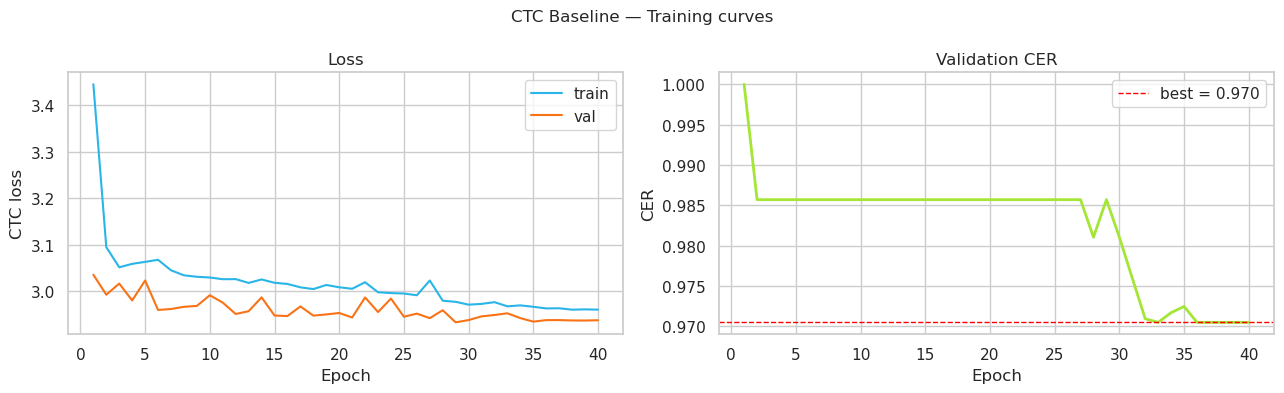

In [8]:
epochs_x = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("CTC Baseline — Training curves", fontsize=12)

axes[0].plot(epochs_x, history["train_loss"], label="train", color="#29b5e8", lw=1.5)
axes[0].plot(epochs_x, history["val_loss"],   label="val",   color="#f97316", lw=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_x, history["val_cer"], color="#a3e635", lw=2)
axes[1].axhline(best_val_cer, color="red", ls="--", lw=1,
                label=f"best = {best_val_cer:.3f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER")
axes[1].set_title(f"Validation CER")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print("=" * 72)
print(" BEST 5 predictions (lowest CER)")
print("=" * 72)
for _, row in results_df.sort_values("cer").head(5).iterrows():
    print(f"CER = {row['cer']:.3f}")
    print(f"  REF : {row['reference']}")
    print(f"  HYP : {row['hypothesis']}")

print()
print("=" * 72)
print(" WORST 5 predictions (highest CER)")
print("=" * 72)
for _, row in results_df.sort_values("cer", ascending=False).head(5).iterrows():
    print(f"CER = {row['cer']:.3f}")
    print(f"  REF : {row['reference']}")
    print(f"  HYP : {row['hypothesis']}")

 BEST 5 predictions (lowest CER)
CER = 0.929
  REF : isolated plank dog pointers.
  HYP : t.
CER = 0.938
  REF : it makes for a nice scissor leg.
  HYP : t.
CER = 0.938
  REF : what do you see?
  HYP : t.
CER = 0.943
  REF : so thursdays are really jam-packed.
  HYP : t.
CER = 0.952
  REF : everybody's eyes open and the game begins.
  HYP : t.

 WORST 5 predictions (highest CER)
CER = 0.992
  REF : low self esteem tends to bring us down and there's a set of thoughts or cognitions that tend to go with low self esteem.
  HYP : .
CER = 0.991
  REF : what i always like to have nearby is my blower, just in case it needs a little extra air and oxygen to get moving.
  HYP : .
CER = 0.990
  REF : this is really going to put focus on shoulder stability of the off shoulder and off hip, at the same time working for balance and coordination and mobility through your torso as you are working.
  HYP : t.
CER = 0.989
  REF : so just because a brand new car has never been titled, doesn't necessarily m

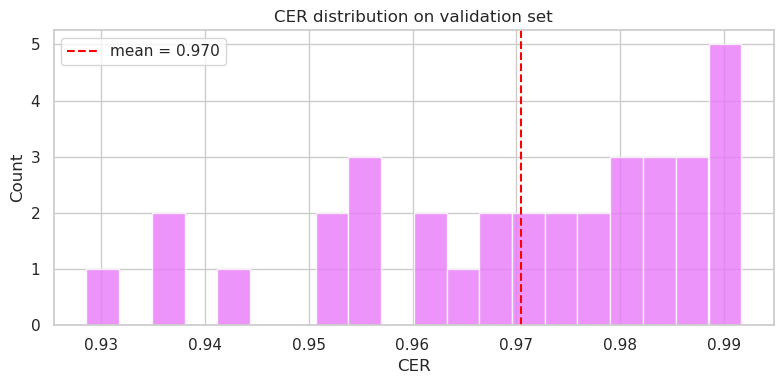

CER stats : mean=0.970  median=0.974  min=0.929  max=0.992


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results_df["cer"], bins=20, color="#e879f9", alpha=0.8, edgecolor="white")
ax.axvline(mean_cer, color="red", ls="--", lw=1.5, label=f"mean = {mean_cer:.3f}")
ax.set_xlabel("CER")
ax.set_ylabel("Count")
ax.set_title("CER distribution on validation set")
ax.legend()
plt.tight_layout()
plt.show()

print(f"CER stats : mean={results_df['cer'].mean():.3f}  "
      f"median={results_df['cer'].median():.3f}  "
      f"min={results_df['cer'].min():.3f}  "
      f"max={results_df['cer'].max():.3f}")

## 8 · Summary

| Component | Detail |
|-----------|--------|
| Input | `(T, FEAT_DIM)` full-clip landmark sequences (hands + pose + face) |
| Encoder | Input projection + 2-layer bidirectional LSTM |
| Head | Linear → log-softmax over char vocabulary |
| Loss | `nn.CTCLoss(blank=0, zero_infinity=True)` |
| Decode | Greedy CTC collapse: argmax → remove repeats → remove blank |
| Metric | CER = Levenshtein(hyp, ref) / len(ref) |

**Next steps:**
- Use the full How2Sign dataset (larger corpus)
- Replace BiLSTM with a Transformer encoder
- Add beam search with an n-gram or neural LM
- Evaluate WER alongside CER